In [1]:
#补全，手动梯度下降，alpha选择，三段划分，
#权重初始化，网格搜索超参数，正则化，
''' 
#vocab_size
block_size
#N
train_size,dev_size,test_size
embedding_dim
hidden_size

'''
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F

words=open("names.txt","r").read().splitlines()
#构建映射
chars=sorted(list(set(''.join(words))))
stoi={'.':0}
stoi.update({s:i+1 for i,s in enumerate(chars)})
itos={i:s for s,i in stoi.items()}
#参数1
vocab_size=len(stoi)
#参数2 
block_size=3
X=[]
Y=[]
#构建训练样本，改用滑动窗口法
for w in words:
    context=[stoi['.']]*block_size

    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)
#参数3
N=len(X)

#划分X到三个子集，分别是train,dev,test,参数4
train_size,dev_size,test_size=0.8,0.1,0.1
g=torch.Generator().manual_seed(2147483647)
indices=torch.randperm(N)
n1=int(N*train_size)
n2=int(N*(train_size+dev_size))
X_train,Y_train=X[indices[:n1]],Y[indices[:n1]]
X_dev,Y_dev=X[indices[n1:n2]],Y[indices[n1:n2]]
X_test,Y_test=X[indices[n2:]],Y[indices[n2:]]


## 本文件（02-3）在 02-2 基础上新增的内容

在原有手写反向传播 MLP 的基础上新增两项优化，所有新增/修改的地方都在代码里用
`# === 新增 ===` / `# === 修改 ===` 注释标出：

1. **BatchNorm**：在 `z1`（改名 `hprebn`）之后、`tanh` 之前插入批归一化层，用批统计量训练、
   用滑动平均的 `bnmean_running` / `bnvar_running` 做验证集推理。因为 BatchNorm 会减去均值，
   `b1` 的作用被完全抵消，所以顺手把 `b1` 去掉了。
2. **学习率衰减**：训练进行到 80% 步数后，学习率从 0.1 降到 0.01，让 loss 后期收敛得更平稳。

梯度核对 cell 里同步加入了 BatchNorm 的手写反向传播公式（化简后的解析形式），用于验证正确性。


In [2]:
#初始化参数,参数5
embedding_dim=10
C=torch.randn((vocab_size,embedding_dim),generator=g)
#隐藏层凯明初始化
#参数6
hidden_size=200
W1=torch.randn((embedding_dim*block_size,hidden_size),generator=g)*(5/3)/(embedding_dim*block_size)**0.5
# === 新增: BatchNorm 参数 ===
# 有了BatchNorm对hprebn做归一化,b1的偏置效果会被减均值这一步抵消掉,所以去掉b1,
# 改用BatchNorm自己的可学习缩放bngain和平移bnbias
bngain = torch.ones((1, hidden_size))
bnbias = torch.zeros((1, hidden_size))
# 训练时用当前batch的均值/方差,验证/测试时改用下面这两个滑动平均值
bnmean_running = torch.zeros((1, hidden_size))
bnvar_running = torch.ones((1, hidden_size))
# === 新增结束 ===
#输出层权重初始化处理
W2=torch.randn((hidden_size,vocab_size),generator=g)*0.01
b2=torch.zeros((vocab_size,))
#参数列表
parameters=[W2,b2,W1,C,bngain,bnbias]  # === 修改: 去掉b1, 加入bngain,bnbias ===
num_parameters=sum(p.nelement() for p in parameters)

In [3]:
#参数7，8，9
iters=10000
alpha=0.1
batch_size=32
# === 新增: 学习率衰减 ===
# 训练进行到80%后,学习率降为原来的1/10,帮助loss在后期更平稳地收敛
alpha_decay_start = int(iters * 0.8)
alpha_decayed = alpha / 10
# === 新增结束 ===
#可视化准备
lossi=[]
ud_c,ud_w1,ud_w2=[],[],[]#计算更新步长与当前权重的标准差比例
snapshot_z1={}
snapshot_a1={}

In [4]:
"""
梯度核对:用PyTorch autograd验证手写反向传播是否正确
在正式训练循环之前单独跑一次这段,确认无误后再开始10000轮训练
（本版本加入了BatchNorm,所以核对内容也同步加上了BatchNorm的手写反向传播）
"""


#用同一份初始化参数,但开 requires_grad

g_check = torch.Generator().manual_seed(2147483647)
batch_size_check = 32

# 复制一份参数,开启梯度追踪(不能直接在原参数上设requires_grad)
C_c  = C.clone().detach().requires_grad_(True)
W1_c = W1.clone().detach().requires_grad_(True)
bngain_c = bngain.clone().detach().requires_grad_(True)  # === 新增 ===
bnbias_c = bnbias.clone().detach().requires_grad_(True)  # === 新增 ===
W2_c = W2.clone().detach().requires_grad_(True)
b2_c = b2.clone().detach().requires_grad_(True)

# 取一批固定的样本,和手写版本用完全相同的数据
ix_check = torch.randint(0, X_train.shape[0], (batch_size_check,), generator=g_check)
X_b_check = X_train[ix_check]
Y_b_check = Y_train[ix_check]

# forward
emb_c = C_c[X_b_check]
emb_flat_c = emb_c.reshape(emb_c.shape[0], -1)
hprebn_c = emb_flat_c @ W1_c  # === 修改: z1 -> hprebn, 不再加b1(BatchNorm前的预激活) ===
# === 新增: BatchNorm前向 ===
bnmean_c = hprebn_c.mean(0, keepdim=True)
bnvar_c = hprebn_c.var(0, keepdim=True, unbiased=True)
bnraw_c = (hprebn_c - bnmean_c) / torch.sqrt(bnvar_c + 1e-5)
z1_c = bngain_c * bnraw_c + bnbias_c
# === 新增结束 ===
a1_c = torch.tanh(z1_c)
logits_c = a1_c @ W2_c + b2_c
loss_c = F.cross_entropy(logits_c, Y_b_check)

loss_c.backward()

#手写版本和下面的循环一样
emb = C[X_b_check]
emb_flat = emb.reshape(emb.shape[0], -1)
hprebn = emb_flat @ W1  # === 修改 ===
# === 新增: BatchNorm前向(手写版) ===
bnmean = hprebn.mean(0, keepdim=True)
bnvar = hprebn.var(0, keepdim=True, unbiased=True)
bnvar_inv = (bnvar + 1e-5) ** -0.5
bnraw = (hprebn - bnmean) * bnvar_inv
z1 = bngain * bnraw + bnbias
# === 新增结束 ===
a1 = torch.tanh(z1)
logits = a1 @ W2 + b2
logits_max = logits.max(1, keepdim=True).values
logits_shifted = logits - logits_max
counts = logits_shifted.exp()
probs = counts / counts.sum(1, keepdim=True)

dlogits = probs.clone()
dlogits[range(batch_size_check), Y_b_check] -= 1.0
dlogits /= batch_size_check

dW2 = a1.T @ dlogits
db2 = dlogits.sum(0)
da1 = dlogits @ W2.T
dz1 = da1 * (1.0 - a1 ** 2)

# === 新增: BatchNorm反向(化简后的解析公式) ===
dbngain = (dz1 * bnraw).sum(0, keepdim=True)
dbnbias = dz1.sum(0, keepdim=True)
dbnraw = dz1 * bngain
n = batch_size_check
dhprebn = bngain * bnvar_inv / n * (
    n * dbnraw - dbnraw.sum(0) - n / (n - 1) * bnraw * (dbnraw * bnraw).sum(0)
)
# === 新增结束 ===

dW1 = emb_flat.T @ dhprebn  # === 修改: 用dhprebn代替dz1 ===
demb_flat = dhprebn @ W1.T  # === 修改 ===
demb = demb_flat.reshape(emb.shape)
dC = torch.zeros_like(C)
dC.index_add_(0, X_b_check.flatten(), demb.view(-1, demb.shape[-1]))

# 核对
def compare(name, manual, auto):
    match = torch.allclose(manual, auto, atol=1e-6)
    max_diff = (manual - auto).abs().max().item()
    status = "✅ 一致" if match else "❌ 不一致"
    print(f"{name:8s}  {status}   最大差异: {max_diff:.2e}")

print("=" * 45)
print("梯度核对结果(手写 vs autograd, 含BatchNorm)")
print("=" * 45)
compare("dW2", dW2, W2_c.grad)
compare("db2", db2, b2_c.grad)
compare("dW1", dW1, W1_c.grad)
compare("dbngain", dbngain, bngain_c.grad)  # === 新增 ===
compare("dbnbias", dbnbias, bnbias_c.grad)  # === 新增 ===
compare("dC ", dC,  C_c.grad)
print("=" * 45)
print(f"手写loss: {(-probs[range(batch_size_check), Y_b_check].log().mean()).item():.6f}")
print(f"autograd loss: {loss_c.item():.6f}")

梯度核对结果(手写 vs autograd, 含BatchNorm)
dW2       ✅ 一致   最大差异: 2.98e-08
db2       ✅ 一致   最大差异: 7.45e-09
dW1       ✅ 一致   最大差异: 9.31e-10
dbngain   ✅ 一致   最大差异: 5.82e-10
dbnbias   ✅ 一致   最大差异: 9.31e-10
dC        ✅ 一致   最大差异: 9.31e-10
手写loss: 3.295091
autograd loss: 3.295091


以上结果说明
1.初始loss接近-ln(1/27),说明初始化的缩放有用
2.和torch的backward结果几乎一致说明手写版正确



In [5]:
#循环训练
for i in range(iters):
    #forward
    #随机采样
    ix=torch.randint(0,X_train.shape[0],(batch_size,),generator=g)
    X_b=X_train[ix]
    emb=C[X_b]
    emb_flat=emb.reshape(emb.shape[0],-1)
    hprebn=emb_flat@W1  # === 修改: z1改名hprebn, 不再加b1(BatchNorm会抵消掉) ===

    # === 新增: BatchNorm前向 ===
    bnmean=hprebn.mean(0,keepdim=True)
    bnvar=hprebn.var(0,keepdim=True,unbiased=True)
    bnvar_inv=(bnvar+1e-5)**-0.5
    bnraw=(hprebn-bnmean)*bnvar_inv
    z1=bngain*bnraw+bnbias
    with torch.no_grad():
        bnmean_running = 0.999*bnmean_running + 0.001*bnmean
        bnvar_running = 0.999*bnvar_running + 0.001*bnvar
    # === 新增结束 ===

    a1=F.tanh(z1)

    if i%100==0 or i==iters-1:
        snapshot_z1.update({i:z1.detach().cpu().numpy().copy()})
        snapshot_a1.update({i:a1.detach().cpu().numpy().copy()})

    logits=a1@W2+b2
    #解决指数问题
    logits_max=logits.max(1,keepdim=True).values
    logits=logits-logits_max
    counts=logits.exp()
    probs=counts/counts.sum(1,keepdim=True)
    loss=-probs[range(batch_size),Y_train[ix]].log().mean()

    lossi.append(loss.item())

    #backward
    dlogits=probs.clone()
    #P-Y
    dlogits[range(batch_size),Y_train[ix]]-=1.0
    #dlogits=1/m(P-Y)=dz2
    dlogits/=batch_size
    dW2=a1.T@dlogits
    db2=dlogits.sum(0)
    da1=dlogits@W2.T
    dz1=da1*(1.0-a1**2)

    # === 新增: BatchNorm反向(化简后的解析公式) ===
    dbngain=(dz1*bnraw).sum(0,keepdim=True)
    dbnbias=dz1.sum(0,keepdim=True)
    dbnraw=dz1*bngain
    n=batch_size
    dhprebn = bngain*bnvar_inv/n * (
        n*dbnraw - dbnraw.sum(0) - n/(n-1)*bnraw*(dbnraw*bnraw).sum(0)
    )
    # === 新增结束 ===

    dW1=emb_flat.T@dhprebn  # === 修改: 用dhprebn代替dz1 ===
    db1_unused=None  # b1已去掉,不再需要
    demb_flat=dhprebn@W1.T  # === 修改 ===
    demb=demb_flat.reshape(emb.shape)
    dC=torch.zeros_like(C)
    '''
    for _ in range(X_b.shape[0]):
        for __ in range(X_b.shape[1]):
            ix=Xb[_,__]
            dC[ix]+=demb[_,__]
    '''
    dC.index_add_(0, X_b.flatten(), demb.view(-1, demb.shape[-1]))
    #图表
    ud_w1.append(torch.log10(alpha*dW1.std()/(W1.std()+1e-8)).item())
    ud_w2.append(torch.log10(alpha*dW2.std()/(W2.std()+1e-8)).item())
    ud_c.append(torch.log10(alpha*dC.std()/(C.std()+1e-8)).item())

    # === 新增: 学习率衰减 ===
    cur_alpha = alpha if i < alpha_decay_start else alpha_decayed
    # === 新增结束 ===

    #更新参数
    W2 -= cur_alpha * dW2  # === 修改: alpha -> cur_alpha ===
    b2 -= cur_alpha * db2
    W1 -= cur_alpha * dW1
    bngain -= cur_alpha * dbngain  # === 新增 ===
    bnbias -= cur_alpha * dbnbias  # === 新增 ===
    C  -= cur_alpha * dC

(1.616761565208435, 3.29974365234375, 1.9585416316986084)

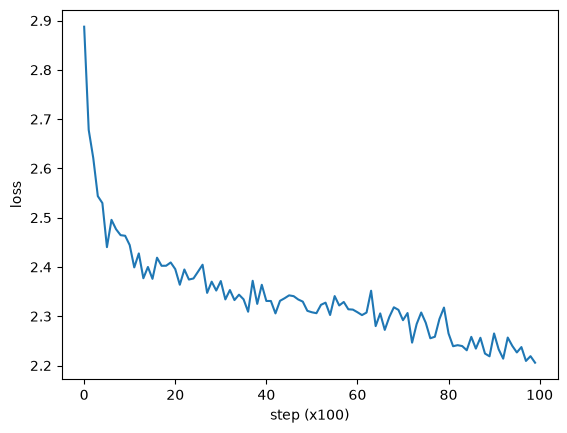

In [6]:
#lossi可视化
plt.plot(torch.tensor(lossi).view(-1, 100).mean(1))  # 每100步取平均,去掉mini-batch噪声
plt.xlabel('step (x100)')
plt.ylabel('loss')
min(lossi),max(lossi),lossi[-1]

In [7]:
@torch.no_grad()
def split_loss(X_split, Y_split):
    emb = C[X_split]
    emb_flat = emb.reshape(emb.shape[0], -1)
    hprebn = emb_flat @ W1  # === 修改: 不再加b1 ===
    # === 新增: 用训练时滑动平均的均值/方差做归一化,而不是当前batch的统计量 ===
    bnraw = (hprebn - bnmean_running) / torch.sqrt(bnvar_running + 1e-5)
    h = torch.tanh(bngain * bnraw + bnbias)
    # === 新增结束 ===
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_split)
    return loss.item()

print(f"train loss: {split_loss(X_train, Y_train):.4f}")
print(f"dev loss:   {split_loss(X_dev, Y_dev):.4f}")

train loss: 2.2124
dev loss:   2.2276


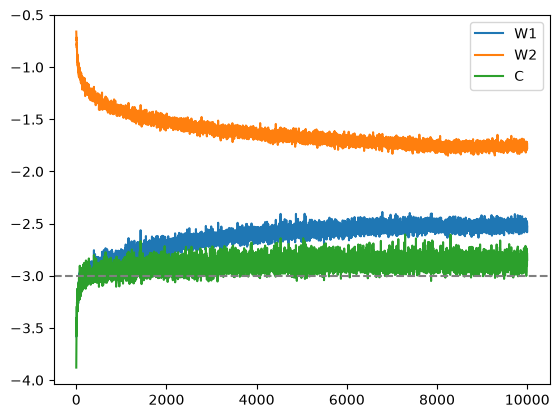

In [8]:
plt.plot(ud_w1, label='W1')
plt.plot(ud_w2, label='W2')
plt.plot(ud_c, label='C')
plt.legend()
plt.axhline(-3, color='gray', linestyle='--')  # 参考线,理想值附近

(array([211., 201., 182., 164., 146., 164., 135., 122., 151., 118., 121.,
        109., 122., 122., 138.,  93.,  88., 106., 122., 102.,  87.,  99.,
         76., 110., 126.,  88.,  90.,  94.,  98., 108.,  79.,  92., 122.,
        127., 119., 137., 105., 125., 134., 127., 154., 126., 135., 139.,
        147., 152., 158., 171., 184., 174.]),
 array([-9.98376727e-01, -9.58433270e-01, -9.18489814e-01, -8.78546298e-01,
        -8.38602841e-01, -7.98659384e-01, -7.58715868e-01, -7.18772411e-01,
        -6.78828955e-01, -6.38885498e-01, -5.98942041e-01, -5.58998525e-01,
        -5.19055068e-01, -4.79111612e-01, -4.39168096e-01, -3.99224639e-01,
        -3.59281182e-01, -3.19337726e-01, -2.79394269e-01, -2.39450753e-01,
        -1.99507296e-01, -1.59563839e-01, -1.19620323e-01, -7.96768665e-02,
        -3.97334099e-02,  2.10046768e-04,  4.01535034e-02,  8.00969601e-02,
         1.20040536e-01,  1.59983993e-01,  1.99927449e-01,  2.39870906e-01,
         2.79814363e-01,  3.19757819e-01,  3.59701

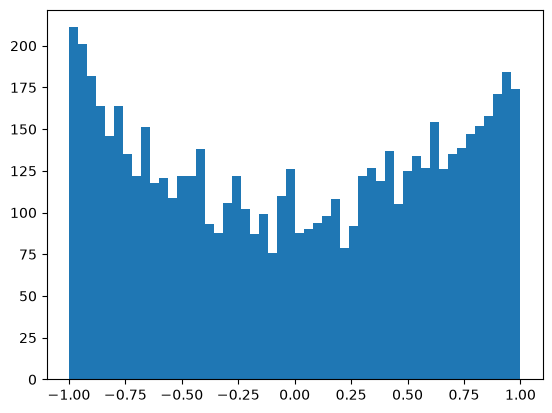

In [9]:
plt.hist(snapshot_a1[iters-1].flatten(), bins=50)

In [10]:
count=(W2>0).sum().item()
W2.shape[0]*W2.shape[1],count


(5400, 2706)